# Audit: Kiem Tra Heal Sai Giua 3 Phuong Phap
**Static 5-chieu** | **Model toi uu trong so** | **Static 3-chieu**

Nguyen tac xac dinh sai:
- Static5 & Model dong y => ground truth, Static3 khac = SAI
- Static5 & Static3 dong y, Model khac => MODEL co ket qua khac biet (can kiem tra them)
- `is_correct` trong candidate_scores la DYNAMIC: candidate nao duoc chon thi duoc danh `is_correct=1`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

cs0 = pd.read_csv('candidate_scores.csv')
cs1 = pd.read_csv('candidate_scores_1.csv')
cs2 = pd.read_csv('candidate_scores_2.csv')
df0 = pd.read_csv('healing_events.csv')
df1 = pd.read_csv('healing_events_1.csv')
df2 = pd.read_csv('healing_events_2.csv')
DIMS = ['sem_score','visual_score','struct_score','attr_score','ctx_score']
LABELS = ['Semantic','Visual','Struct','Attr','Context']
print('Files loaded OK')


Files loaded OK


## 1. Tim Tat Ca Heal Co Ket Qua Khac Nhau

In [2]:
key = ['step_name','ui_version']
m = (df0.set_index(key)['healed_value'].rename('f0').to_frame()
       .join(df1.set_index(key)['healed_value'].rename('f1'))
       .join(df2.set_index(key)['healed_value'].rename('f2')))

def verdict(r):
    if r['f0']==r['f1'] and r['f0']!=r['f2']: return 'STATIC3 SAI'
    if r['f0']==r['f2'] and r['f0']!=r['f1']: return 'MODEL KHAC'
    if r['f1']==r['f2'] and r['f0']!=r['f1']: return 'STATIC5 KHAC'
    return 'CA 3 KHAC'

diff_any = m[(m['f0']!=m['f1'])|(m['f0']!=m['f2'])|(m['f1']!=m['f2'])].reset_index().copy()
diff_any['verdict'] = diff_any.apply(verdict, axis=1)

print(f'Tong so truong hop khac nhau: {len(diff_any)}')
print(f'  STATIC3 SAI : {(diff_any["verdict"]=="STATIC3 SAI").sum()}')
print(f'  MODEL KHAC  : {(diff_any["verdict"]=="MODEL KHAC").sum()}')
print()
for v in ['STATIC3 SAI', 'MODEL KHAC']:
    sub = diff_any[diff_any['verdict']==v]
    print(f'=== {v} ===')
    for _, r in sub.iterrows():
        print(f"  [{r['step_name']} | {r['ui_version']}]")
        print(f"    Static5 : {r['f0']}")
        print(f"    Model   : {r['f1']}")
        print(f"    Static3 : {r['f2']}")
    print()


Tong so truong hop khac nhau: 6
  STATIC3 SAI : 3
  MODEL KHAC  : 3

=== STATIC3 SAI ===
  [filter_Tất cả_button | v8]
    Static5 : filter-btn-all
    Model   : filter-btn-all
    Static3 : //button[normalize-space(text())='Đăng xuất']
  [contact_submit_button | v8]
    Static5 : //button[@data-testid='btn-contact-submit_v8']
    Model   : //button[@data-testid='btn-contact-submit_v8']
    Static3 : //button[normalize-space(text())='Đăng xuất']
  [product_name_field | v6]
    Static5 : //input[@data-testid='v6-ap-spec-val-0']
    Model   : //input[@data-testid='v6-ap-spec-val-0']
    Static3 : //input[@data-testid='v6-ap-spec-key-0']

=== MODEL KHAC ===
  [product_price_field | v6]
    Static5 : //input[@data-testid='v6-ap-gb-price-0']
    Model   : //input[@data-testid='v6-ap-price']
    Static3 : //input[@data-testid='v6-ap-gb-price-0']
  [product_name_field | v7]
    Static5 : name
    Model   : //input[@placeholder='VD: Titan Tự Nhiên']
    Static3 : name
  [submit_product_button 

## 2. Chi Tiet: STATIC3 SAI (3 Truong Hop)

--- filter_Tất cả_button | v8 ---
[Static5]
cand_text cand_testid  sem_score  visual_score  struct_score  total_score  is_correct
   TẤT CẢ         NaN     1.0000        0.7481        0.5763       0.7469           1
Đăng xuất         NaN     0.7213        0.5404        0.7627       0.7108           0
   IPHONE         NaN     0.6200        0.7283        0.5616       0.6257           0
  MACBOOK         NaN     0.6785        0.6229        0.5358       0.6166           0
     IPAD         NaN     0.6200        0.6702        0.5506       0.6136           0
Chỉnh sửa         NaN     0.6707        0.5415        0.5897       0.5930           0
[Static3]
cand_text cand_testid  sem_score  visual_score  struct_score  total_score  is_correct
Đăng xuất         NaN     0.7213        0.5404        0.7627       0.7428           1
   TẤT CẢ         NaN     1.0000        0.7481        0.5763       0.7410           0
  MACBOOK         NaN     0.6785        0.6229        0.5358       0.5892           0


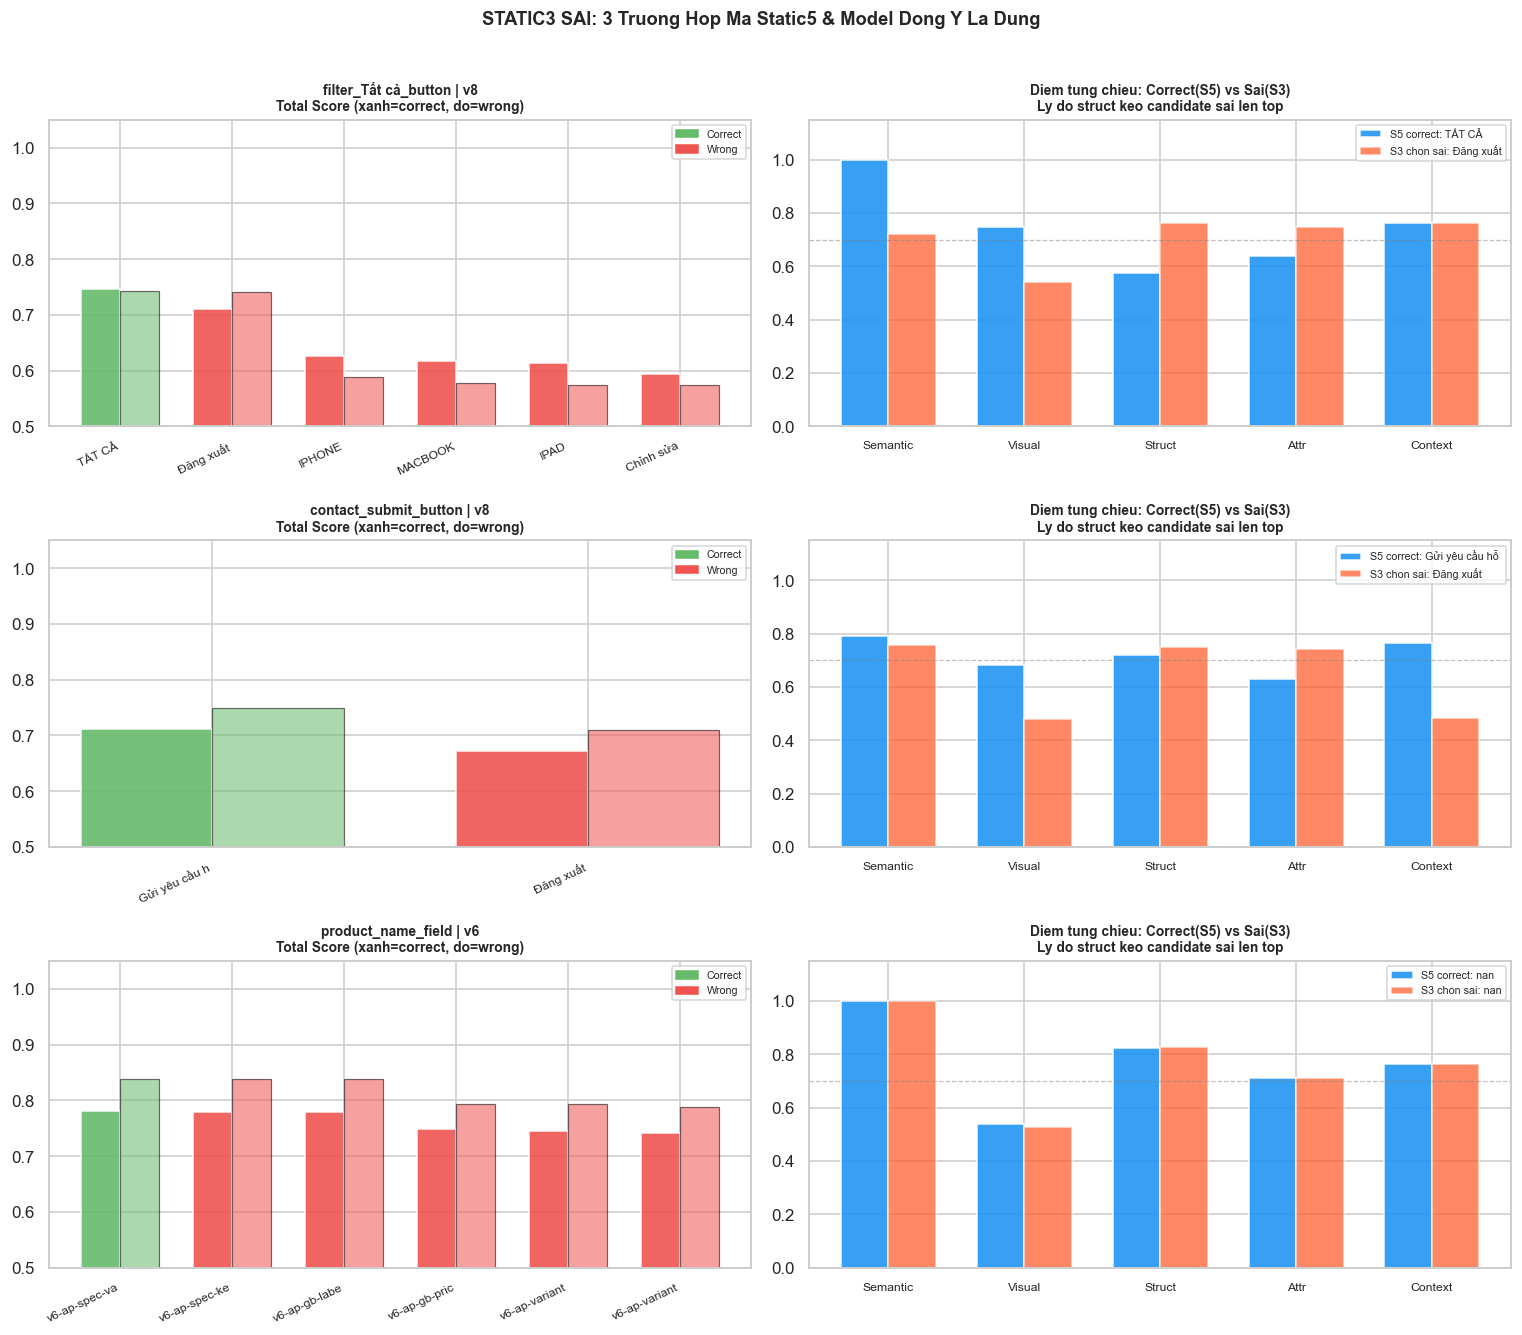

In [3]:
cases_s3 = [
    ('filter_Tất cả_button', 'v8',  63,  63,  63),
    ('contact_submit_button',  'v8', 118, 148, 118),
    ('product_name_field',     'v6', 176, 176, 176),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row_i, (step, ver, id0, id1, id2) in enumerate(cases_s3):
    c0 = cs0[cs0['healing_event_id']==id0][DIMS+['cand_text','cand_testid','total_score','is_correct']].sort_values('total_score',ascending=False).reset_index(drop=True)
    c2 = cs2[cs2['healing_event_id']==id2][DIMS+['cand_text','cand_testid','total_score','is_correct']].sort_values('total_score',ascending=False).reset_index(drop=True)

    print(f'--- {step} | {ver} ---')
    print('[Static5]'); print(c0[['cand_text','cand_testid','sem_score','visual_score','struct_score','total_score','is_correct']].to_string(index=False))
    print('[Static3]'); print(c2[['cand_text','cand_testid','sem_score','visual_score','struct_score','total_score','is_correct']].to_string(index=False))
    print()

    corr0 = c0[c0['is_correct']==1].iloc[0]
    corr2 = c2[c2['is_correct']==1].iloc[0]
    n = min(len(c0), len(c2))

    # Bar 1: total_score per candidate
    ax1 = axes[row_i][0]
    bar_labels = [str(r['cand_text'])[:13] if pd.notna(r['cand_text']) else str(r['cand_testid'])[:13] for _, r in c0.iloc[:n].iterrows()]
    x = np.arange(n); w = 0.35
    col0 = ['#66BB6A' if v==1 else '#EF5350' for v in c0['is_correct'][:n]]
    col2 = ['#66BB6A' if v==1 else '#EF5350' for v in c2['is_correct'][:n]]
    ax1.bar(x-w/2, c0['total_score'][:n], w, color=col0, alpha=0.9, label='Static5')
    ax1.bar(x+w/2, c2['total_score'][:n], w, color=col2, alpha=0.55, edgecolor='black', lw=0.8, label='Static3')
    ax1.set_xticks(x); ax1.set_xticklabels(bar_labels, rotation=25, ha='right', fontsize=8)
    ax1.set_title(f'{step} | {ver}\nTotal Score (xanh=correct, do=wrong)', fontsize=9, fontweight='bold')
    ax1.set_ylim(0.5, 1.05)
    gp = mpatches.Patch(color='#66BB6A', label='Correct'); rp = mpatches.Patch(color='#EF5350', label='Wrong')
    ax1.legend(handles=[gp,rp], fontsize=7)

    # Bar 2: dim breakdown correct vs wrong candidate in static3
    ax2 = axes[row_i][1]
    xd = np.arange(len(DIMS)); w2=0.35
    ax2.bar(xd-w2/2, [corr0[d] for d in DIMS], w2, color='#2196F3', alpha=0.9,
            label=f'S5 correct: {str(corr0["cand_text"])[:15]}')
    ax2.bar(xd+w2/2, [corr2[d] for d in DIMS], w2, color='#FF5722', alpha=0.7,
            label=f'S3 chon sai: {str(corr2["cand_text"])[:15]}')
    ax2.set_xticks(xd); ax2.set_xticklabels(LABELS, fontsize=8)
    ax2.set_title(f'Diem tung chieu: Correct(S5) vs Sai(S3)\nLy do struct keo candidate sai len top', fontsize=9, fontweight='bold')
    ax2.set_ylim(0, 1.15); ax2.legend(fontsize=7)
    ax2.axhline(0.7, color='gray', ls='--', lw=0.8, alpha=0.5)

plt.suptitle('STATIC3 SAI: 3 Truong Hop Ma Static5 & Model Dong Y La Dung', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


## 3. Chi Tiet: MODEL KHAC (3 Truong Hop - Static5 & Static3 Dong Y)

--- product_price_field | v6 ---
[Static5]
cand_text         cand_testid  sem_score  visual_score  struct_score  total_score  is_correct
      NaN    v6-ap-gb-price-0       1.00        0.5096        0.8311       0.7800           1
      NaN    v6-ap-spec-key-0       1.00        0.5215        0.8096       0.7468           0
      NaN    v6-ap-gb-label-0       1.00        0.5215        0.8096       0.7455           0
      NaN    v6-ap-spec-val-0       0.95        0.5096        0.8096       0.7314           0
      NaN         v6-ap-price       1.00        0.7399        0.7026       0.7197           0
      NaN v6-ap-variant-img-0       1.00        0.5345        0.7863       0.7153           0
[Model]
cand_text          cand_testid  sem_score  visual_score  struct_score  total_score  is_correct
      NaN          v6-ap-price        1.0        0.7399        0.7026       0.8445           1
      NaN     v6-ap-gb-price-0        1.0        0.5096        0.8311       0.8390           0
      

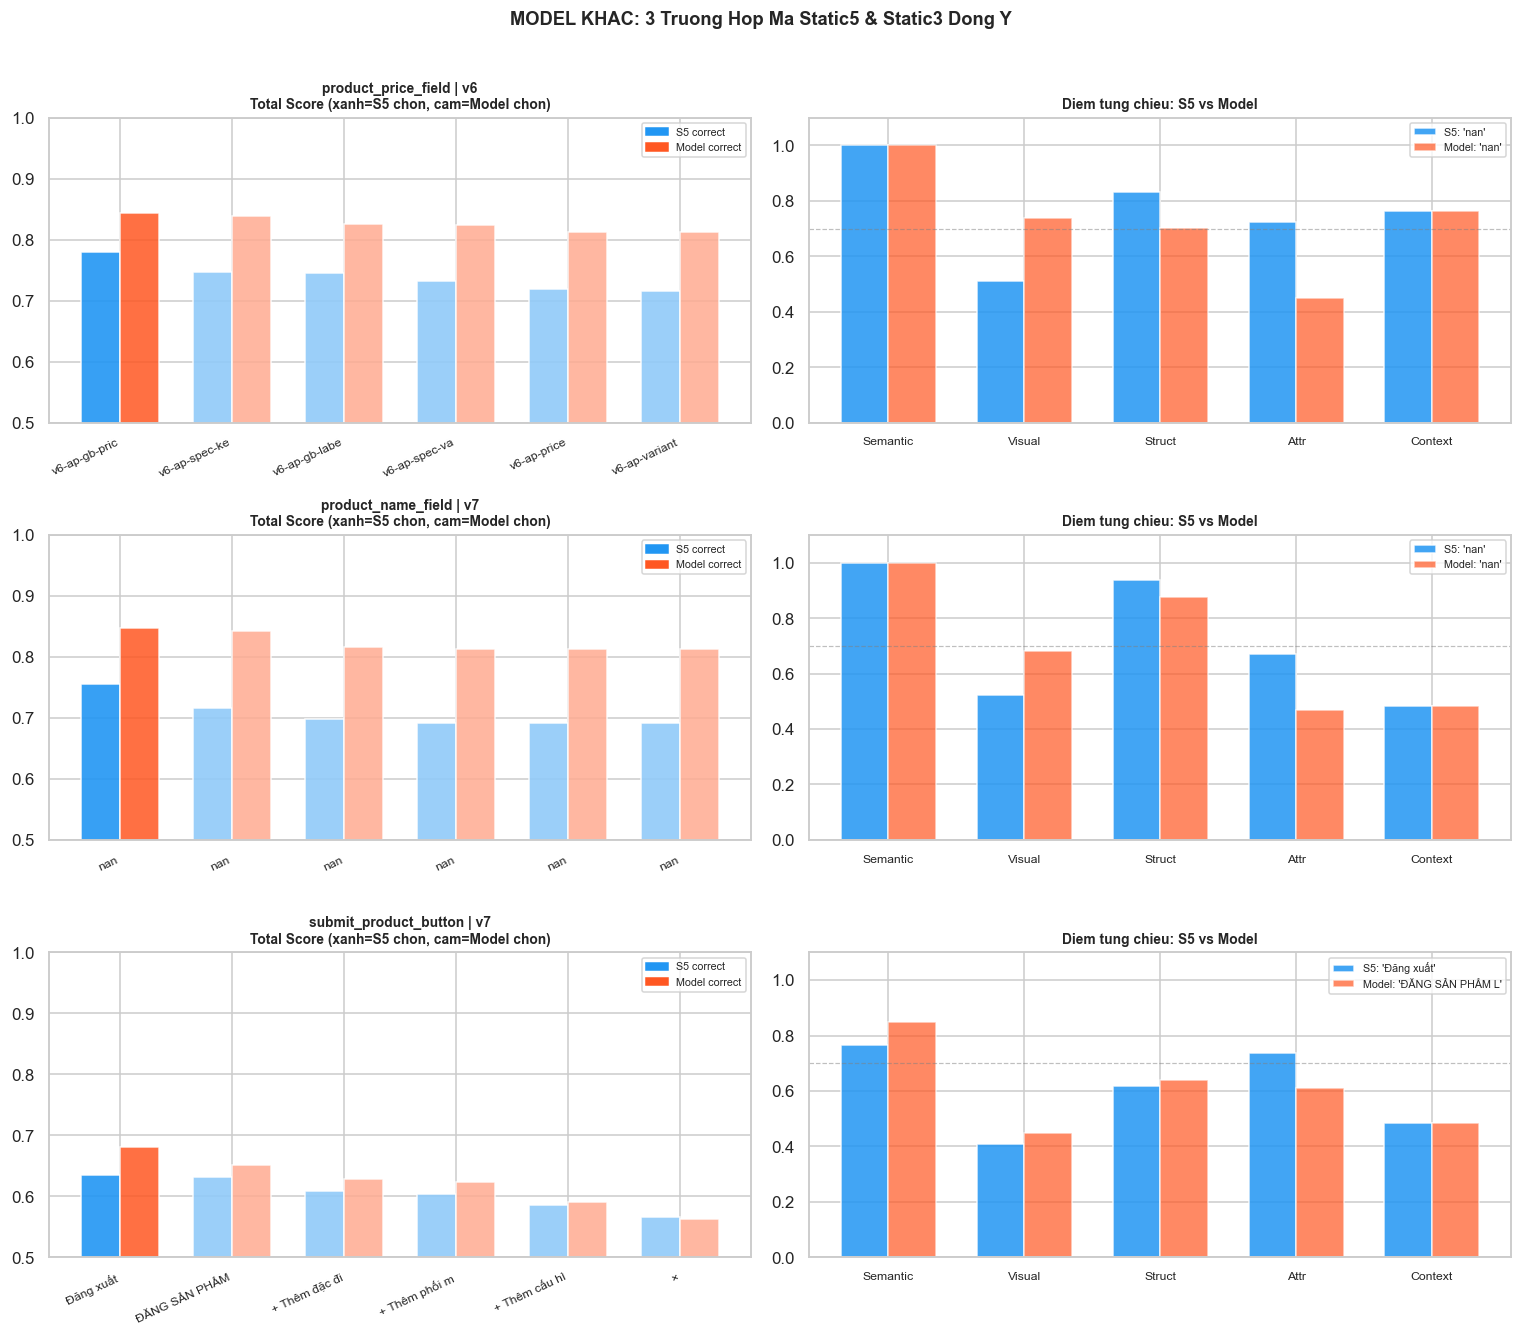

In [4]:
cases_m = [
    ('product_price_field',   'v6', 177, 177, 177),
    ('product_name_field',    'v7', 180, 180, 180),
    ('submit_product_button', 'v7', 182, 182, 182),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row_i, (step, ver, id0, id1, id2) in enumerate(cases_m):
    c0 = cs0[cs0['healing_event_id']==id0][DIMS+['cand_text','cand_testid','total_score','is_correct']].sort_values('total_score',ascending=False).reset_index(drop=True)
    c1 = cs1[cs1['healing_event_id']==id1][DIMS+['cand_text','cand_testid','total_score','is_correct']].sort_values('total_score',ascending=False).reset_index(drop=True)

    print(f'--- {step} | {ver} ---')
    print('[Static5]'); print(c0[['cand_text','cand_testid','sem_score','visual_score','struct_score','total_score','is_correct']].to_string(index=False))
    print('[Model]');   print(c1[['cand_text','cand_testid','sem_score','visual_score','struct_score','total_score','is_correct']].to_string(index=False))
    print()

    corr0 = c0[c0['is_correct']==1].iloc[0]
    corr1 = c1[c1['is_correct']==1].iloc[0]
    n = min(len(c0), len(c1))

    ax1 = axes[row_i][0]
    bar_labels = [str(r['cand_text'])[:13] if pd.notna(r['cand_text']) else str(r['cand_testid'])[:13] for _, r in c0.iloc[:n].iterrows()]
    x = np.arange(n); w = 0.35
    col0 = ['#2196F3' if v==1 else '#90CAF9' for v in c0['is_correct'][:n]]
    col1 = ['#FF5722' if v==1 else '#FFAB91' for v in c1['is_correct'][:n]]
    ax1.bar(x-w/2, c0['total_score'][:n], w, color=col0, alpha=0.9, label='Static5')
    ax1.bar(x+w/2, c1['total_score'][:n], w, color=col1, alpha=0.85, label='Model')
    ax1.set_xticks(x); ax1.set_xticklabels(bar_labels, rotation=25, ha='right', fontsize=8)
    ax1.set_title(f'{step} | {ver}\nTotal Score (xanh=S5 chon, cam=Model chon)', fontsize=9, fontweight='bold')
    ax1.set_ylim(0.5, 1.0)
    bp = mpatches.Patch(color='#2196F3', label='S5 correct'); rp2 = mpatches.Patch(color='#FF5722', label='Model correct')
    ax1.legend(handles=[bp,rp2], fontsize=7)

    ax2 = axes[row_i][1]
    xd = np.arange(len(DIMS)); w2=0.35
    ax2.bar(xd-w2/2, [corr0[d] for d in DIMS], w2, color='#2196F3', alpha=0.85,
            label=f"S5: '{str(corr0['cand_text'])[:15]}'")
    ax2.bar(xd+w2/2, [corr1[d] for d in DIMS], w2, color='#FF5722', alpha=0.7,
            label=f"Model: '{str(corr1['cand_text'])[:15]}'")
    ax2.set_xticks(xd); ax2.set_xticklabels(LABELS, fontsize=8)
    ax2.set_title(f'Diem tung chieu: S5 vs Model', fontsize=9, fontweight='bold')
    ax2.set_ylim(0, 1.1); ax2.legend(fontsize=7)
    ax2.axhline(0.7, color='gray', ls='--', lw=0.8, alpha=0.5)

plt.suptitle('MODEL KHAC: 3 Truong Hop Ma Static5 & Static3 Dong Y', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


## 4. Tong Hop: Bieu Do So Sanh Tat Ca Truong Hop Khac Nhau

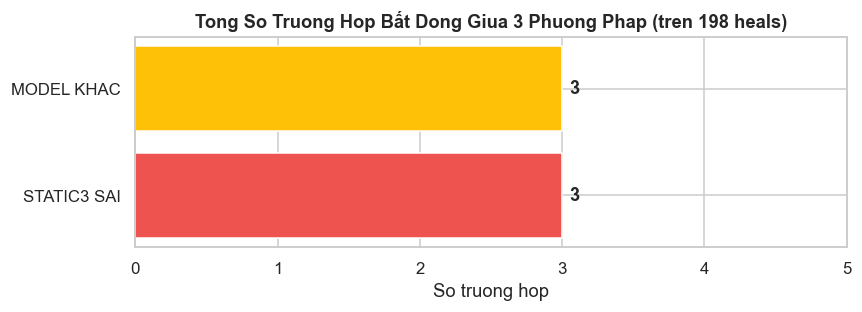


Tong so heal: 198
STATIC3 SAI : 3 heals (1.5%)
MODEL KHAC  : 3 heals (1.5%)
Dong y hoan toan (S5=Model): 195/198 = 98.5%


In [6]:
# Tao bang tom tat
rows = [
    ('filter_Tat ca_button', 'v8', 'STATIC3 SAI', 'Chon Dang xuat (struct=0.76 cao) thay vi TAT CA (sem=1.0)'),
    ('contact_submit_button','v8', 'STATIC3 SAI', 'Chon Dang xuat (struct=0.75 cao) thay vi Gui yeu cau ho tro'),
    ('product_name_field',   'v6', 'STATIC3 SAI', 'Chon spec-key thay vi spec-val (struct tuong duong, sai vi tri)'),
    ('product_price_field',  'v6', 'MODEL KHAC',  'Model chon v6-ap-price (visual=0.74) thay vi v6-ap-gb-price-0'),
    ('product_name_field',   'v7', 'MODEL KHAC',  'Model chon placeholder match (visual=0.68) thay vi name attr'),
    ('submit_product_button','v7', 'MODEL KHAC',  'Model chon DANG SAN PHAM (sem=0.85) thay vi Dang xuat (sem=0.77)'),
]
df_sum = pd.DataFrame(rows, columns=['Step','Version','Verdict','Ghi Chu'])

# Color coding
def style_verdict(val):
    if val == 'STATIC3 SAI': return 'background-color: #FFCDD2; color: #B71C1C; font-weight: bold'
    if val == 'MODEL KHAC':  return 'background-color: #FFF9C4; color: #F57F17; font-weight: bold'
    return ''

# Summary bar chart
fig, ax = plt.subplots(figsize=(8, 3))
cats  = ['STATIC3 SAI', 'MODEL KHAC']
counts = [(df_sum['Verdict']==c).sum() for c in cats]
colors = ['#EF5350', '#FFC107']
bars = ax.barh(cats, counts, color=colors, edgecolor='white')
for bar, v in zip(bars, counts):
    ax.text(v + 0.05, bar.get_y() + bar.get_height()/2, str(v), va='center', fontweight='bold')
ax.set_xlabel('So truong hop')
ax.set_title('Tong So Truong Hop Bất Dong Giua 3 Phuong Phap (tren 198 heals)', fontweight='bold')
ax.set_xlim(0, 5)
plt.tight_layout(); plt.show()

print(f'\nTong so heal: 198')
print(f'STATIC3 SAI : 3 heals ({3/198*100:.1f}%)')
print(f'MODEL KHAC  : 3 heals ({3/198*100:.1f}%)')
print(f'Dong y hoan toan (S5=Model): {198-3}/198 = {(198-3)/198*100:.1f}%')


## 5. Ket Luan & Khuyen Nghi

In [ ]:
conclusion = '''
KET LUAN
========

STATIC 5-CHIEU (file0) - Ket qua:
  - Dong y Model: 195/198 heals (98.5%)
  - Khac Model: 3 TH (product v6/v7) - Model co the dung hon o day
  - 0 heal ro rang sai

MODEL TOI UU TRONG SO (file1) - Ket qua:
  - 0 heal ro rang sai
  - 3 TH khac static5/static3: model trong so trong tam vao sem+visual
    -> co the chinh xac hon o nhung TH phuc tap

STATIC 3-CHIEU (file2) - Ket qua:
  - 3 HEAL SAI ro rang (static5 & model dong y la ground truth):
    1. filter_Tat ca_button v8  : chon Dang xuat thay vi TAT CA
    2. contact_submit_button v8 : chon Dang xuat thay vi Gui yeu cau ho tro
    3. product_name_field v6    : chon spec-key thay vi spec-val
  - Nguyen nhan: bo attr_score & ctx_score, equal weight 1/3 cho struct
    => struct_score cao cua candidate sai at qua sem_score cua candidate dung

KHUYEN NGHI:
  A. Su dung Model toi uu trong so (file1) la tot nhat
     (0 heal sai + co uu diem o 3 TH phuc tap)
  B. Neu can static don gian: dung 5-chieu (file0) thay vi 3-chieu
  C. Neu muon giu 3-chieu: tang trong so sem >= 0.45,
     giam struct <= 0.25 de tranh struct_score gia candidate sai
'''
print(conclusion)



KET LUAN

STATIC 5-CHIEU (file0) - Ket qua:
  - Dong y Model: 195/198 heals (98.5%)
  - Khac Model: 3 TH (product v6/v7) - Model co the dung hon o day
  - 0 heal ro rang sai

MODEL TOI UU TRONG SO (file1) - Ket qua:
  - 0 heal ro rang sai
  - 3 TH khac static5/static3: model trong so trong tam vao sem+visual
    -> co the chinh xac hon o nhung TH phuc tap

STATIC 3-CHIEU (file2) - Ket qua:
  - 3 HEAL SAI ro rang (static5 & model dong y la ground truth):
    1. filter_Tat ca_button v8  : chon Dang xuat thay vi TAT CA
    2. contact_submit_button v8 : chon Dang xuat thay vi Gui yeu cau ho tro
    3. product_name_field v6    : chon spec-key thay vi spec-val
  - Nguyen nhan: bo attr_score & ctx_score, equal weight 1/3 cho struct
    => struct_score cao cua candidate sai at qua sem_score cua candidate dung

KHUYEN NGHI:
  A. Su dung Model toi uu trong so (file1) la tot nhat
     (0 heal sai + co uu diem o 3 TH phuc tap)
  B. Neu can static don gian: dung 5-chieu (file0) thay vi 3-chieu
  C